# Taipei House：台北房價迴歸教學範例

1. 讀取與檢視房價資料  
2. 觀察目標欄位 `總價` 與重要特徵的關係  
3. 使用 `pd.get_dummies()` 處理類別欄位  
4. 使用 `train_test_split` 切分訓練資料與測試資料  
5. 使用 `StandardScaler` 做標準化  
6. 使用 `LinearRegression` 建立房價預測模型  
7. 使用 `RMSE` 評估預測誤差  


| 欄位名稱 | 中文說明 | 原始型態 | 資料角色 | 內容說明 | 缺漏值 | 建模時的處理建議 |
|---|---|---|---|---|---:|---|
| `行政區` | 房屋所在行政區 | `object` | 類別特徵 | 例如文山區、信義區、松山區、大安區 | 0 | 需要進行類別編碼，例如 `pd.get_dummies()` |
| `土地面積` | 土地面積 | `float64` | 數值特徵 | 房屋交易所包含的土地面積，推測單位為平方公尺 | 0 | 可作為房價預測特徵；若使用線性模型，可考慮標準化 |
| `建物總面積` | 建物總面積 | `float64` | 數值特徵 | 建物交易面積，通常是影響房價的重要因素 | 0 | 很重要的預測特徵；若使用線性模型，可考慮標準化 |
| `屋齡` | 房屋年齡 | `float64` | 數值特徵 | 房屋已使用年數，數值越大通常代表屋齡越高 | 0 | 可作為模型特徵；可能與房價呈現負相關 |
| `樓層` | 交易物件所在樓層 | `int64` | 數值 / 序位特徵 | 表示該房屋位於第幾樓 | 0 | 可直接作為模型特徵 |
| `總樓層` | 建物總樓層數 | `int64` | 數值特徵 | 表示整棟建築物共有幾層樓 | 0 | 可直接作為模型特徵 |
| `用途` | 房屋用途編碼 | `int64` | 類別 / 編碼特徵 | 資料中以 `0`、`1` 表示不同用途；原始 CSV 未附明確對照表 | 0 | 可先當成二元類別特徵使用；不建議未查證就解釋 0/1 的實際含義 |
| `房數` | 房間數 | `int64` | 數值特徵 | 房屋格局中的房間數 | 0 | 可直接作為模型特徵 |
| `廳數` | 客廳 / 餐廳數 | `int64` | 數值特徵 | 房屋格局中的廳數 | 0 | 可直接作為模型特徵 |
| `衛數` | 衛浴數 | `int64` | 數值特徵 | 房屋格局中的衛浴數 | 0 | 可直接作為模型特徵 |
| `電梯` | 是否有電梯 | `int64` | 二元類別特徵 | `0`、`1` 編碼；通常可理解為是否有電梯 | 0 | 可直接作為 0/1 特徵使用 |
| `車位類別` | 車位種類 | `object` | 類別特徵 | 例如無、坡道平面、坡道機械、升降機械等 | 0 | 需要進行類別編碼，例如 `pd.get_dummies()` |
| `交易日期` | 不動產交易日期 | `object` | 日期欄位 | 例如 `2019/10/6` | 0 | 入門範例可先不使用；進階可轉成年度、月份等特徵 |
| `經度` | 房屋位置經度 | `float64` | 數值 / 空間特徵 | 表示房屋所在位置的 longitude | 0 | 可作為地理位置特徵使用 |
| `緯度` | 房屋位置緯度 | `float64` | 數值 / 空間特徵 | 表示房屋所在位置的 latitude | 0 | 可作為地理位置特徵使用 |
| `總價` | 房屋交易總價 | `int64` | 目標欄位 | 房屋交易總價，推測單位為萬元 | 0 | 迴歸任務的預測目標 `y` |

In [1]:
# 忽略警告訊息
import warnings
warnings.filterwarnings("ignore")

# 匯入必要的套件
import matplotlib.pyplot as plt

# 設定字型，確保中文能顯示微軟正黑體
plt.rcParams["font.family"] = "Microsoft JhengHei"


# 設定數學字型，確保負號能正常顯示
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["mathtext.fontset"] = "dejavusans"

In [2]:
# ============================================================
# 1. 讀取資料與初步檢視
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 讀取資料。
# 使用時請確認 Taipei_house.csv 和這個 notebook 放在同一個資料夾。
data = pd.read_csv("./Taipei_house.csv")

print("資料形狀：", data.shape)
print("欄位名稱：")
print(data.columns.tolist())

display(data.head())

# 檢查每個欄位是否有遺漏值。
print("每個欄位的遺漏值數量：")
display(data.isna().sum())

# describe() 可以快速觀察數值欄位的平均數、標準差、最小值與最大值。
display(data.describe().round(2))

資料形狀： (12429, 16)
欄位名稱：
['行政區', '土地面積', '建物總面積', '屋齡', '樓層', '總樓層', '用途', '房數', '廳數', '衛數', '電梯', '車位類別', '交易日期', '經度', '緯度', '總價']


,行政區,土地面積,建物總面積,屋齡,樓層,總樓層,用途,房數,廳數,衛數,電梯,車位類別,交易日期,經度,緯度,總價
0,文山區,33.81,109.42,38.996009,3,5,0,3,2,2,0,無,2019/10/6,121.552517,25.004507,1000
1,文山區,32.19,163.53,23.781460,3,11,0,3,2,2,1,坡道平面,2019/4/28,121.559133,24.983199,2100
2,文山區,60.25,204.79,0.744711,1,10,0,3,2,3,1,無,2019/10/23,121.576052,24.988665,6720
3,文山區,16.99,80.31,0.506513,5,10,0,3,2,2,1,坡道平面,2019/7/28,121.576052,24.988665,1110
4,文山區,25.98,86.73,36.099304,4,5,0,3,2,2,0,無,2019/9/28,121.563486,24.995213,800


每個欄位的遺漏值數量：


行政區      0
土地面積     0
建物總面積    0
屋齡       0
樓層       0
總樓層      0
用途       0
房數       0
廳數       0
衛數       0
電梯       0
車位類別     0
交易日期     0
經度       0
緯度       0
總價       0
dtype: int64

,土地面積,建物總面積,屋齡,樓層,總樓層,用途,房數,廳數,衛數,電梯,經度,緯度,總價
count,12429.00,12429.00,12429.00,12429.00,12429.00,12429.00,12429.00,12429.00,12429.00,12429.00,12429.00,12429.00,12429.00
mean,25.91,126.44,22.52,5.93,10.47,0.11,2.62,1.71,1.66,0.81,121.56,25.02,2483.75
std,20.94,81.78,14.36,3.80,5.27,0.31,1.10,0.55,0.73,0.39,0.01,0.02,2610.14
min,0.00,0.07,-7.04,1.00,1.00,0.00,0.00,0.00,0.00,0.00,121.52,24.97,1.00
25%,12.30,76.53,9.61,3.00,6.00,0.00,2.00,1.00,1.00,1.00,121.55,25.00,1235.00
50%,22.86,112.36,24.24,5.00,10.00,0.00,3.00,2.00,2.00,1.00,121.56,25.03,1950.00
75%,33.05,156.44,34.53,8.00,14.00,0.00,3.00,2.00,2.00,1.00,121.57,25.04,2888.00
max,387.81,1157.42,53.93,30.00,38.00,1.00,13.00,8.00,13.00,1.00,121.61,25.07,60741.00


## 2. 視覺化觀察資料

這裡先用兩張圖觀察資料：

1. `總價` 的分布：看房價大多集中在哪個範圍。  
2. `建物總面積` 與 `總價` 的關係：通常建物面積越大，總價可能越高。

這些圖不是模型訓練的一部分，而是幫助我們理解資料。


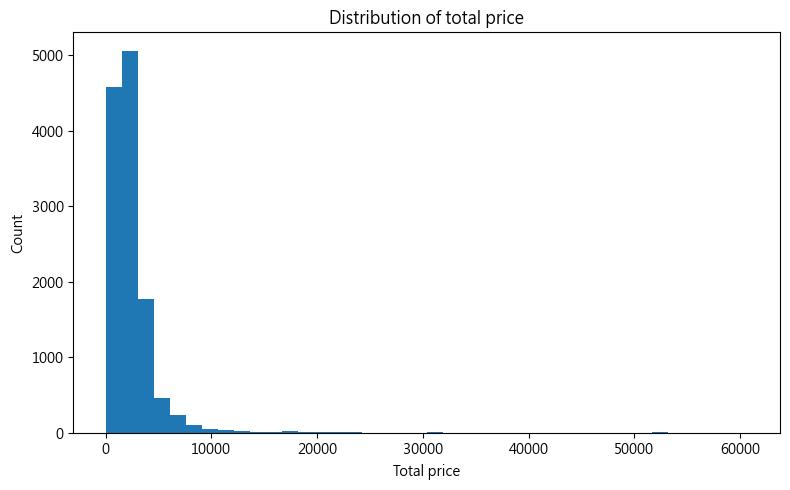

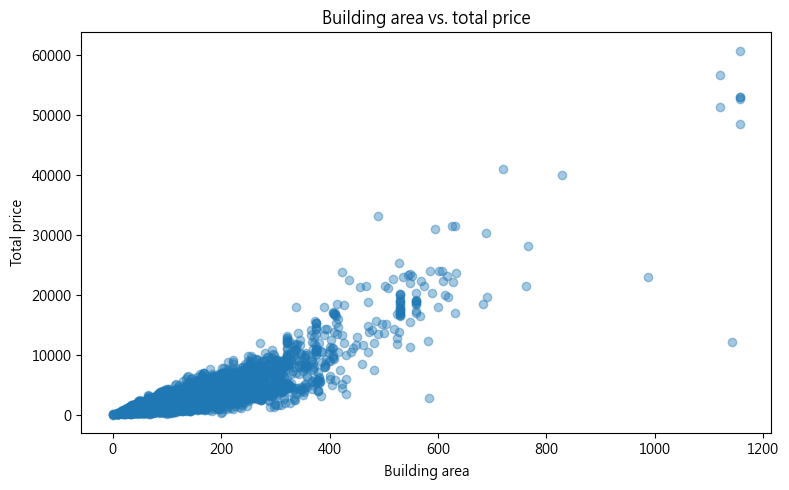

In [3]:
# ============================================================
# 2. 視覺化：總價分布、建物總面積與總價的關係
# ============================================================

work = data.copy()

# 圖 1：觀察總價分布。
plt.figure(figsize=(8, 5))
plt.hist(work["總價"], bins=40)
plt.xlabel("Total price")
plt.ylabel("Count")
plt.title("Distribution of total price")
plt.tight_layout()
plt.show()

# 圖 2：觀察建物總面積與總價的關係。
plt.figure(figsize=(8, 5))
plt.scatter(work["建物總面積"], work["總價"], alpha=0.4)
plt.xlabel("Building area")
plt.ylabel("Total price")
plt.title("Building area vs. total price")
plt.tight_layout()
plt.show()

In [4]:
# ============================================================
# 3. 建立特徵 X 與目標 y，並進行類別欄位編碼
# ============================================================
# 本範例要預測的目標欄位是「總價」。
#
# 為了讓範例不要太複雜：
# 1. 不使用「交易日期」，因為日期處理需要額外轉換。
# 2. 使用 pd.get_dummies() 把「行政區」與「車位類別」轉成 0/1 欄位。
# 3. 其他數值欄位直接作為模型特徵。

target_name = "總價"

feature_data = work.drop(columns=[target_name, "交易日期"])
y = work[target_name]

category_features = ["行政區", "車位類別"]

X = pd.get_dummies(
    feature_data,
    columns=category_features,
    drop_first=True,
    dtype=int
)

print("轉換後的特徵數量：", X.shape[1])
print("轉換後的前幾個欄位名稱：")
print(X.columns[:10].tolist())

display(X.head())

轉換後的特徵數量： 22
轉換後的前幾個欄位名稱：
['土地面積', '建物總面積', '屋齡', '樓層', '總樓層', '用途', '房數', '廳數', '衛數', '電梯']


,土地面積,建物總面積,屋齡,樓層,總樓層,用途,房數,廳數,衛數,電梯,...,行政區_大安區,行政區_文山區,行政區_松山區,車位類別_其他,車位類別_升降平面,車位類別_升降機械,車位類別_坡道平面,車位類別_坡道機械,車位類別_塔式車位,車位類別_無
0,33.81,109.42,38.996009,3,5,0,3,2,2,0,...,0,1,0,0,0,0,0,0,0,1
1,32.19,163.53,23.781460,3,11,0,3,2,2,1,...,0,1,0,0,0,0,1,0,0,0
2,60.25,204.79,0.744711,1,10,0,3,2,3,1,...,0,1,0,0,0,0,0,0,0,1
3,16.99,80.31,0.506513,5,10,0,3,2,2,1,...,0,1,0,0,0,0,1,0,0,0
4,25.98,86.73,36.099304,4,5,0,3,2,2,0,...,0,1,0,0,0,0,0,0,0,1


In [5]:
# ============================================================
# 4. 切分訓練資料與測試資料，並進行標準化
# ============================================================
# 線性迴歸本身不一定要求標準化。
# 但本資料的欄位尺度差異很大，例如：
#   - 經度、緯度是 100 左右或 20 左右
#   - 建物總面積可能是數十到數百
#   - 房數、廳數、衛數通常是小整數
#
# 為了讓係數比較容易比較，本範例使用 StandardScaler。
#
# 重要：
# scaler 只能用 X_train 做 fit。
# X_test 只能使用訓練資料學到的標準化規則做 transform，
# 這樣才不會發生資料外洩。

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0
)

scaler = StandardScaler()

X_train_scaled_array = scaler.fit_transform(X_train)
X_test_scaled_array = scaler.transform(X_test)

# 轉回 DataFrame，方便後面查看欄位名稱與係數。
X_train_scaled = pd.DataFrame(
    X_train_scaled_array,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled_array,
    columns=X_test.columns,
    index=X_test.index
)

print("訓練資料筆數：", X_train_scaled.shape[0])
print("測試資料筆數：", X_test_scaled.shape[0])

訓練資料筆數： 9943
測試資料筆數： 2486


Linear Regression 測試結果
RMSE： 1056.1146


,真實總價,預測總價
5018,1340,783.73
5183,2800,2248.52
9506,460,-541.27
6526,1458,1397.40
5333,1071,2559.73
1501,2570,2672.23
9413,730,141.02
2475,1438,1194.45
10970,3050,3289.02
5010,2168,2223.18


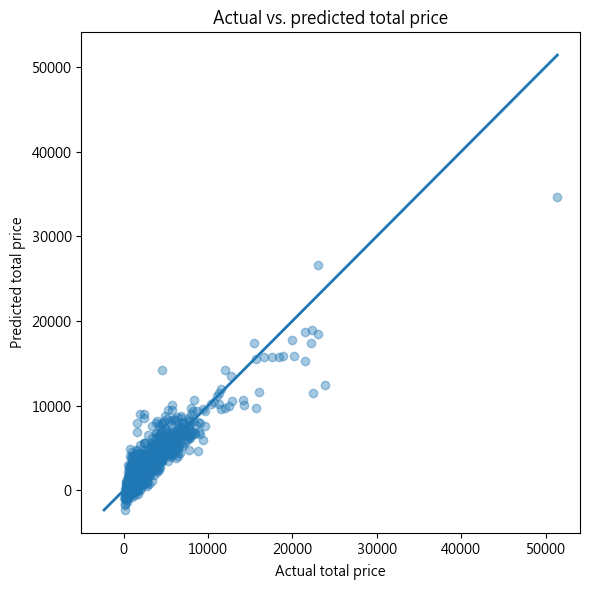

In [6]:
# ============================================================
# 5. 建立線性迴歸模型，並使用 RMSE 評估模型
# ============================================================
# LinearRegression 是迴歸問題中最基本、最具代表性的模型之一。
#
# RMSE 的意思是 Root Mean Squared Error。
# 它可以理解成「模型預測總價時，平均大約會差多少」。
# RMSE 越小，代表模型的預測誤差越小。

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Linear Regression 測試結果")
print("RMSE：", round(rmse, 4))

# 建立真實值與預測值對照表，方便觀察模型預測情況。
result_table = pd.DataFrame({
    "真實總價": y_test,
    "預測總價": y_pred
})

display(result_table.head(10).round(2))

# 視覺化：真實值 vs 預測值。
# 如果點越接近斜線，代表預測越接近真實值。
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.4)

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot([min_value, max_value], [min_value, max_value], linewidth=2)
plt.xlabel("Actual total price")
plt.ylabel("Predicted total price")
plt.title("Actual vs. predicted total price")
plt.tight_layout()
plt.show()

係數絕對值最大的前 10 個特徵：


,特徵,係數,係數絕對值
1,建物總面積,2709.7545,2709.7545
6,房數,-440.8420,440.8420
11,緯度,362.9743,362.9743
13,行政區_文山區,-263.7122,263.7122
18,車位類別_坡道平面,-236.5200,236.5200
21,車位類別_無,187.3875,187.3875
14,行政區_松山區,-181.4080,181.4080
8,衛數,167.1789,167.1789
2,屋齡,-155.0932,155.0932
12,行政區_大安區,116.9056,116.9056


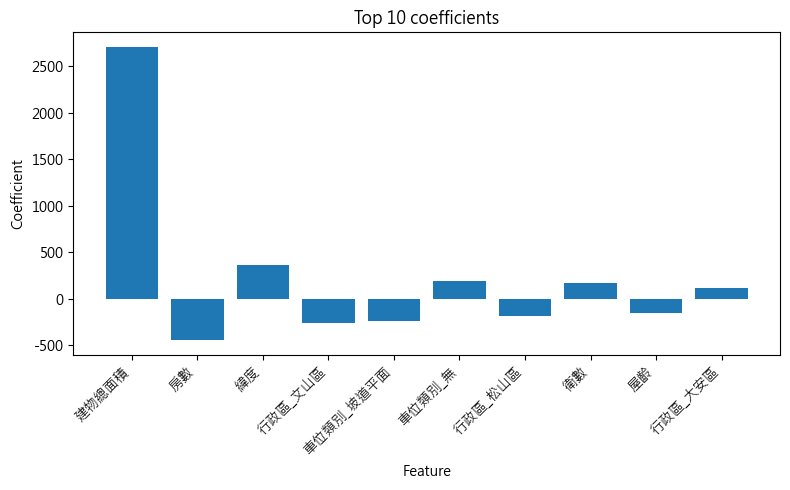

In [7]:
# ============================================================
# 6. 查看模型係數
# ============================================================
# 因為前面已經做過標準化，所以係數大小比較能用來觀察
# 哪些特徵對模型預測的影響比較明顯。
#
# 注意：
# 線性迴歸係數只能代表模型學到的線性關係，
# 不能直接解釋成因果關係。

coef_table = pd.DataFrame({
    "特徵": X_train_scaled.columns,
    "係數": model.coef_
})

coef_table["係數絕對值"] = coef_table["係數"].abs()
coef_table = coef_table.sort_values("係數絕對值", ascending=False)

print("係數絕對值最大的前 10 個特徵：")
display(coef_table.head(10).round(4))

plt.figure(figsize=(8, 5))
plt.bar(coef_table.head(10)["特徵"], coef_table.head(10)["係數"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Feature")
plt.ylabel("Coefficient")
plt.title("Top 10 coefficients")
plt.tight_layout()
plt.show()